### Import Libraries

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [19]:

df = pd.read_csv("../data/cleaned_data.csv")

print(df.head())

  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  


### Churn Distribution

In [20]:

print("========== CHURN DISTRIBUTION ==========")

print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

========== CHURN DISTRIBUTION ==========
Churn
0    447
1     53
Name: count, dtype: int64

Churn Percentage:
Churn
0    89.4
1    10.6
Name: proportion, dtype: float64



### Visualization 1: Churn Distribution


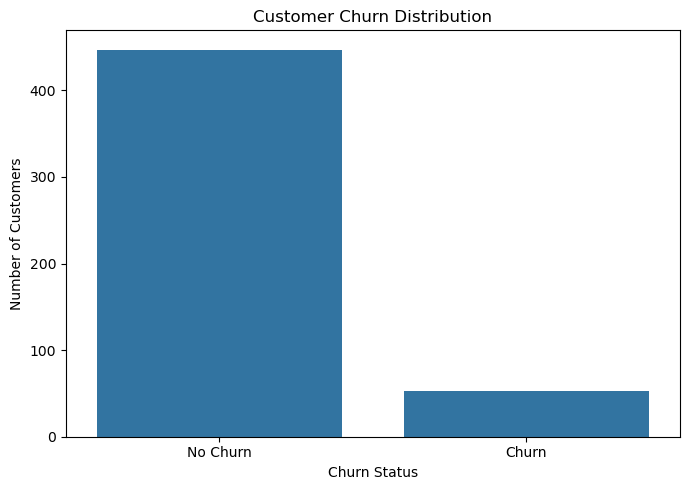

In [21]:

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.xticks(
    ticks=[0, 1],
    labels=["No Churn", "Churn"]
)

plt.tight_layout()
plt.show()

## Insight

Out of 500 customers, 447 customers (89.4%) did not churn, while 53 customers (10.6%) churned.

Although the majority of customers remained with the company, the churned customer segment represents a potential business concern. Further analysis is required to identify the characteristics associated with customer churn.

### Visualization 2: Churn by Contract Type

In [22]:


contract_churn = (
    df.groupby("Contract")["Churn"]
    .mean()
    .reset_index()
)

contract_churn["Churn_Rate"] = contract_churn["Churn"] * 100

print(contract_churn)

         Contract     Churn  Churn_Rate
0  Month-to-month  0.205882   20.588235
1        One year  0.043011    4.301075
2        Two year  0.069444    6.944444


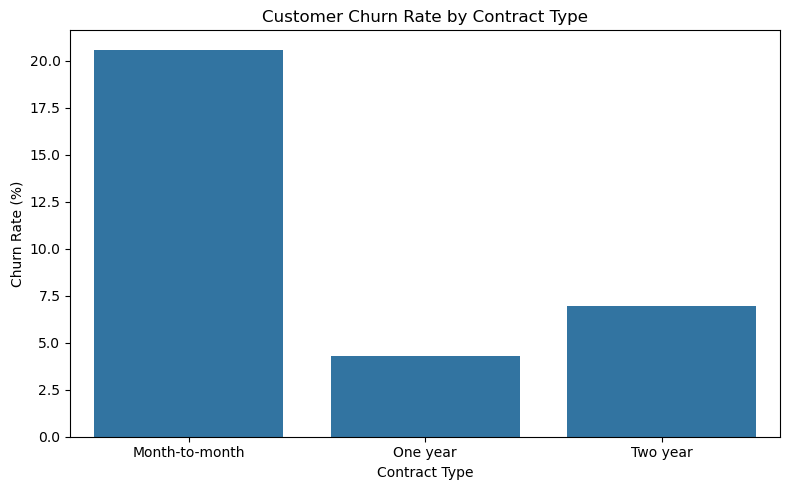

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Churn_Rate"
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

### Insight

This visualization compares the customer churn rate across different contract types.

The analysis helps identify whether customers with certain contract types are more likely to leave the company. Contract-related churn patterns can help the business design targeted customer retention strategies.

### Business Insight

Customers with month-to-month contracts have the highest churn rate at approximately 20.59%.

Customers with one-year contracts have the lowest churn rate at approximately 4.30%, while customers with two-year contracts have a churn rate of approximately 6.94%.

This suggests that customers without longer-term contract commitments may be more likely to leave the company. The business should investigate retention strategies for month-to-month customers, such as loyalty benefits or incentives to move to longer-term contracts.

### Visualization 3: Churn by Payment Method

In [24]:


payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .mean()
    .reset_index()
)

payment_churn["Churn_Rate"] = payment_churn["Churn"] * 100

print(payment_churn)

      PaymentMethod     Churn  Churn_Rate
0     Bank Transfer  0.069182    6.918239
1       Credit Card  0.134831   13.483146
2  Electronic Check  0.110429   11.042945


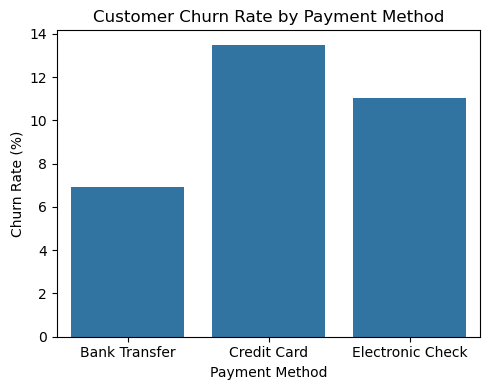

In [26]:
plt.figure(figsize=(5, 4))

sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="Churn_Rate"
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

# plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Business Insight

Customers using Credit Card as their payment method have the highest churn rate at approximately 13.48%.

Customers using Electronic Check have a churn rate of approximately 11.04%, while customers using Bank Transfer have the lowest churn rate at approximately 6.92%.

This suggests that payment method may be associated with customer churn behavior. The business should further investigate why customers using certain payment methods have higher churn rates and consider improving the payment experience or offering targeted retention incentives.

### Visualization 4: Monthly Charges Distribution

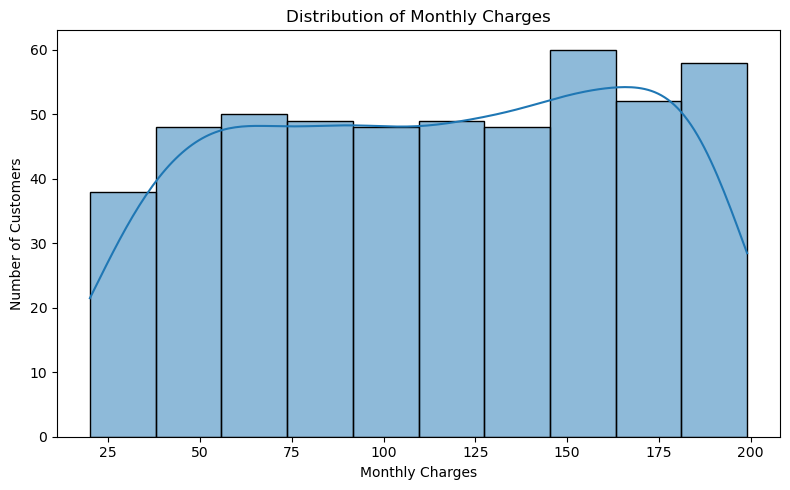

In [9]:

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Insight

The Monthly Charges distribution shows how customer charges are spread across different price ranges.

This visualization helps identify whether customers are concentrated within specific monthly charge ranges and whether the distribution contains unusually high or low values.

Further analysis will compare Monthly Charges between churned and non-churned customers to determine whether pricing is associated with customer churn.

### Visualization 5: Customer Tenure Distribution

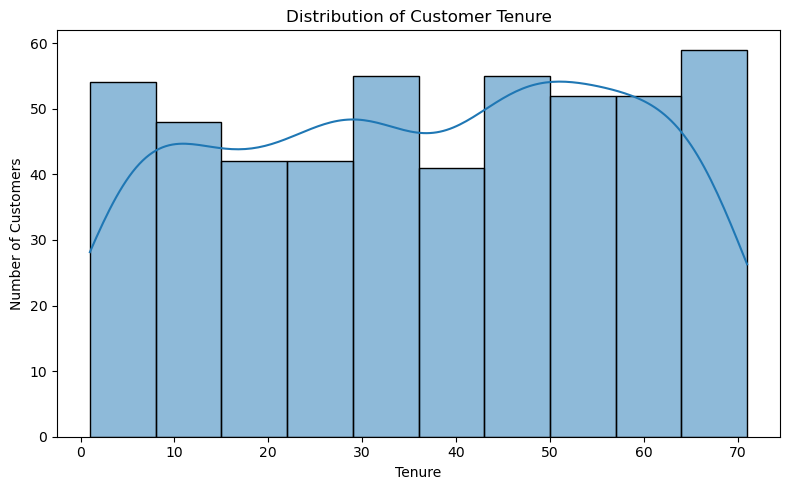

In [10]:


plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Tenure",
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Insight

The customer tenure distribution shows how long customers have been associated with the company.

This analysis helps identify whether customers are concentrated in particular tenure ranges. Further analysis will compare the tenure of churned and non-churned customers to determine whether customer duration is associated with churn.

### Visualization 6: Tenure vs Monthly Charges

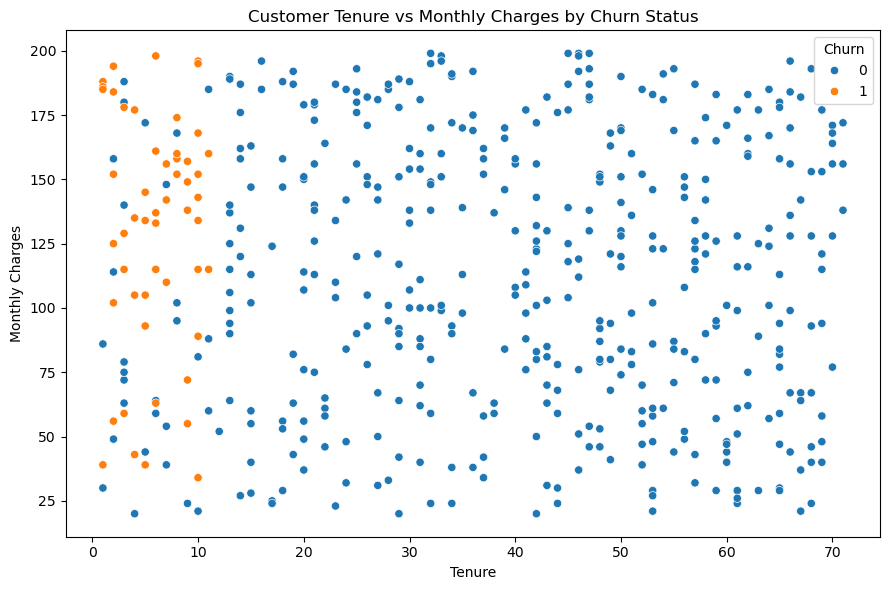

In [11]:

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Tenure",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Customer Tenure vs Monthly Charges by Churn Status")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

### Insight

This visualization compares customer tenure and monthly charges based on churn status.

It helps identify whether churned customers appear to have different tenure or monthly charge patterns compared to customers who remained with the company.

Further statistical analysis will be performed to validate whether these observed differences are statistically significant.

### Correlation Analysis

In [12]:

numerical_columns = df.select_dtypes(include="number")

correlation = numerical_columns.corr()

print(correlation)

                  Tenure  MonthlyCharges  TotalCharges  SeniorCitizen  \
Tenure          1.000000       -0.059655     -0.005677      -0.040001   
MonthlyCharges -0.059655        1.000000     -0.042280      -0.105695   
TotalCharges   -0.005677       -0.042280      1.000000       0.016360   
SeniorCitizen  -0.040001       -0.105695      0.016360       1.000000   
Churn          -0.509208        0.107381      0.004250      -0.018114   

                   Churn  
Tenure         -0.509208  
MonthlyCharges  0.107381  
TotalCharges    0.004250  
SeniorCitizen  -0.018114  
Churn           1.000000  


### Visualization 7: Correlation Heatmap

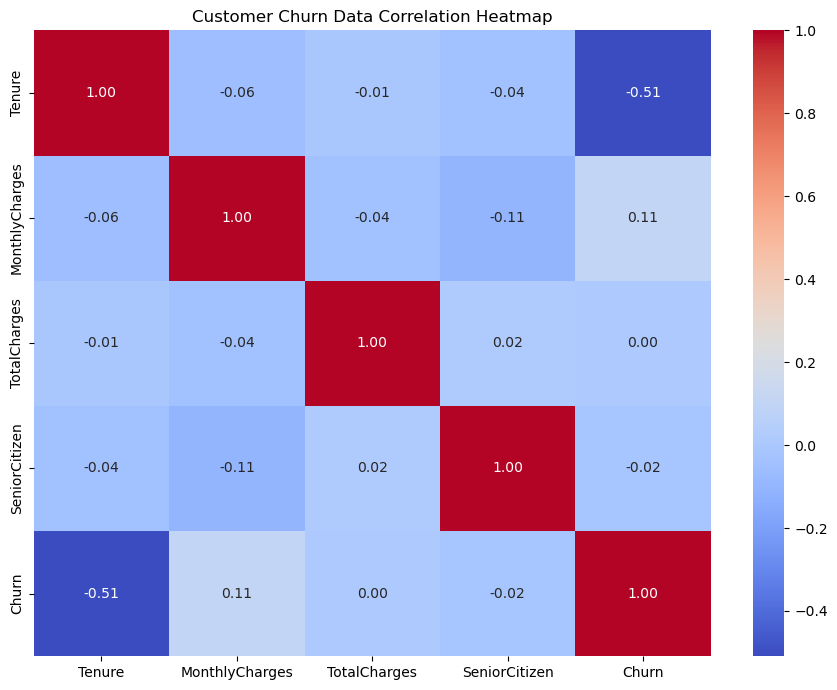

In [14]:


plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Customer Churn Data Correlation Heatmap")

plt.tight_layout()
plt.show()

## Correlation Insight

The correlation heatmap shows the linear relationships between numerical variables.

The strongest relationship with customer churn will be examined further during the advanced statistical analysis phase.

Correlation indicates association between variables but does not prove that one variable causes another.

# Exploratory Data Analysis Summary

The exploratory data analysis identified several important customer churn patterns.

## Key Findings

- The overall customer churn rate is 10.6%.
- Month-to-month contract customers have the highest churn rate at approximately 20.59%.
- One-year contract customers have the lowest churn rate at approximately 4.30%.
- Credit Card customers have the highest churn rate among the payment methods at approximately 13.48%.
- Bank Transfer customers have the lowest churn rate at approximately 6.92%.
- Customer tenure and monthly charges show different patterns across churned and non-churned customers.
- Correlation analysis provides insights into relationships between numerical variables.

These findings will be examined further using statistical analysis and hypothesis testing in the next phase.

Correlation represents association between variables and does not prove causation.